# 05 - LightGBM Threshold Tuning

This notebook improves the initial LightGBM workflow by tuning the classification threshold.

The model hyperparameters stay unchanged. The goal is to reduce false negatives by changing the probability cutoff used to convert predicted probabilities into class labels.

## 1. Why Tune the Threshold?

The previous LightGBM model had a competitive ROC-AUC, which means its predicted probabilities ranked patients reasonably well. However, using the default threshold of `0.50` produced more false negatives than XGBoost.

In heart disease prediction, false negatives are especially important because they are patients with heart disease who are incorrectly classified as low-risk. Lowering the threshold can increase recall and reduce false negatives, usually at the cost of more false positives.

To avoid tuning directly on the test set, this notebook selects the threshold using an internal validation split from the existing training data. The original test set remains untouched until final evaluation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluate import evaluate_scores_at_threshold, write_results_markdown

In [2]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_DIR

WindowsPath('d:/代码集/Python/heart-disease-lightgbm/data/processed')

## 2. Load the Existing Processed Split

This notebook uses the same processed train/test files as the baseline and first LightGBM notebooks. It does not redo preprocessing and does not create a new final test split.

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze("columns")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (736, 32)
X_test shape: (184, 32)
y_train shape: (736,)
y_test shape: (184,)


In [4]:
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0
assert X_train.columns.equals(X_test.columns)
assert X_train.select_dtypes(exclude="number").empty
assert X_test.select_dtypes(exclude="number").empty

pd.DataFrame(
    {
        "y_train_count": y_train.value_counts().sort_index(),
        "y_train_proportion": y_train.value_counts(normalize=True).sort_index(),
        "y_test_count": y_test.value_counts().sort_index(),
        "y_test_proportion": y_test.value_counts(normalize=True).sort_index(),
    }
)

,y_train_count,y_train_proportion,y_test_count,y_test_proportion
target,,,,
0,329,0.447011,82,0.445652
1,407,0.552989,102,0.554348


## 3. Create an Internal Validation Split

The original test set should stay reserved for final evaluation. To choose the threshold, the existing training set is split into a smaller training portion and a validation portion.

This does not change the saved train/test split. It is only used inside this notebook to choose a probability cutoff.

In [5]:
X_model_train, X_valid, y_model_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

print(f"X_model_train shape: {X_model_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_model_train shape: {y_model_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_model_train shape: (588, 32)
X_valid shape: (148, 32)
y_model_train shape: (588,)
y_valid shape: (148,)


## 4. Fit LightGBM for Threshold Selection

The model parameters match the first LightGBM baseline. Only the classification threshold is tuned.

In [6]:
lightgbm_params = {
    "objective": "binary",
    "n_estimators": 100,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": 42,
    "verbosity": -1,
}

validation_model = LGBMClassifier(**lightgbm_params)
validation_model.fit(X_model_train, y_model_train)

valid_proba = validation_model.predict_proba(X_valid)[:, 1]
valid_proba[:5]

array([0.48360774, 0.97146936, 0.90403389, 0.14700852, 0.04523924])

## 5. Evaluate Candidate Thresholds

The candidate thresholds range from `0.10` to `0.80`. The selection rule is:

1. Prefer thresholds with validation recall at least `0.95`.
2. Among those, choose the threshold with the best F1 score.
3. Use precision and the larger threshold as tie breakers.

This favors recall while avoiding an unnecessarily low threshold when multiple options perform similarly.

In [7]:
thresholds = np.round(np.arange(0.10, 0.81, 0.01), 2)

validation_threshold_df = pd.DataFrame(
    [
        evaluate_scores_at_threshold("LightGBM validation", y_valid, valid_proba, threshold)
        for threshold in thresholds
    ]
)

min_validation_recall = 0.95
candidate_thresholds = validation_threshold_df[
    validation_threshold_df["Recall"] >= min_validation_recall
]

if not candidate_thresholds.empty:
    selected_threshold_row = candidate_thresholds.sort_values(
        ["F1", "Precision", "Threshold"],
        ascending=[False, False, False],
    ).iloc[0]
else:
    selected_threshold_row = validation_threshold_df.sort_values(
        ["Recall", "F1", "Precision"],
        ascending=[False, False, False],
    ).iloc[0]

selected_threshold = float(selected_threshold_row["Threshold"])
selected_threshold_row

Model              LightGBM validation
Threshold                         0.11
Accuracy                      0.756757
Precision                     0.709091
Recall                         0.95122
F1                              0.8125
ROC-AUC                       0.869549
True Negatives                      34
False Positives                     32
False Negatives                      4
True Positives                      78
Name: 1, dtype: object

In [8]:
validation_threshold_df.loc[
    validation_threshold_df["Threshold"].isin([0.10, selected_threshold, 0.30, 0.40, 0.50])
].sort_values("Threshold")

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,True Negatives,False Positives,False Negatives,True Positives
0,LightGBM validation,0.10,0.756757,0.709091,0.951220,0.812500,0.869549,34,32,4,78
1,LightGBM validation,0.11,0.756757,0.709091,0.951220,0.812500,0.869549,34,32,4,78
20,LightGBM validation,0.30,0.810811,0.781250,0.914634,0.842697,0.869549,45,21,7,75
30,LightGBM validation,0.40,0.790541,0.786517,0.853659,0.818713,0.869549,47,19,12,70
40,LightGBM validation,0.50,0.783784,0.797619,0.817073,0.807229,0.869549,49,17,15,67


## 6. Plot the Threshold Tradeoff

Lower thresholds usually increase recall and reduce false negatives. The tradeoff is lower precision and more false positives.

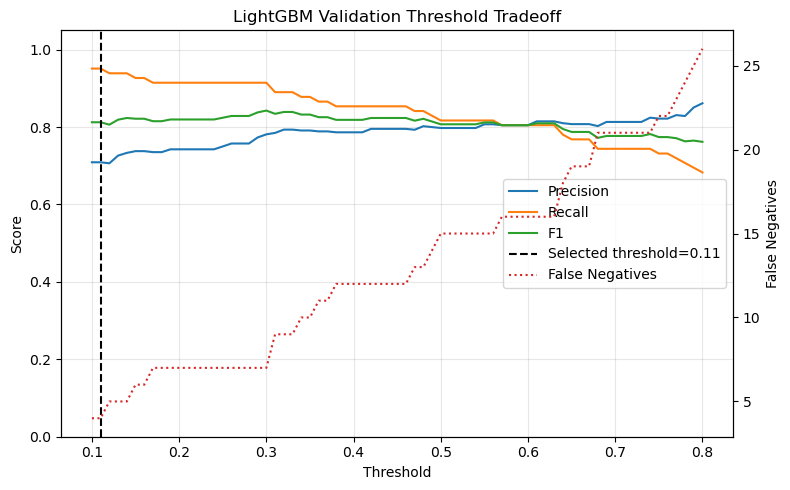

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(validation_threshold_df["Threshold"], validation_threshold_df["Precision"], label="Precision")
ax1.plot(validation_threshold_df["Threshold"], validation_threshold_df["Recall"], label="Recall")
ax1.plot(validation_threshold_df["Threshold"], validation_threshold_df["F1"], label="F1")
ax1.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected threshold={selected_threshold:.2f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    validation_threshold_df["Threshold"],
    validation_threshold_df["False Negatives"],
    color="tab:red",
    linestyle=":" ,
    label="False Negatives",
)
ax2.set_ylabel("False Negatives")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")
ax1.set_title("LightGBM Validation Threshold Tradeoff")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "lightgbm_threshold_tradeoff.png", dpi=150, bbox_inches="tight")

## 7. Evaluate the Selected Threshold on the Test Set

After selecting the threshold from validation data, the final LightGBM model is retrained on the full existing training set. The selected threshold is then evaluated once on the original test set.

In [10]:
final_model = LGBMClassifier(**lightgbm_params)
final_model.fit(X_train, y_train)

test_proba = final_model.predict_proba(X_test)[:, 1]

lightgbm_default_result = evaluate_scores_at_threshold(
    "LightGBM",
    y_test,
    test_proba,
    threshold=0.50,
)

lightgbm_tuned_result = evaluate_scores_at_threshold(
    "LightGBM tuned threshold",
    y_test,
    test_proba,
    threshold=selected_threshold,
)

pd.DataFrame([lightgbm_default_result, lightgbm_tuned_result])

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,True Negatives,False Positives,False Negatives,True Positives
0,LightGBM,0.50,0.842391,0.847619,0.872549,0.859903,0.927666,66,16,13,89
1,LightGBM tuned threshold,0.11,0.766304,0.706294,0.990196,0.824490,0.927666,40,42,1,101


## 8. Save Tuned Confusion Matrix

The tuned threshold should be judged by the new false negative count and the increase in false positives.

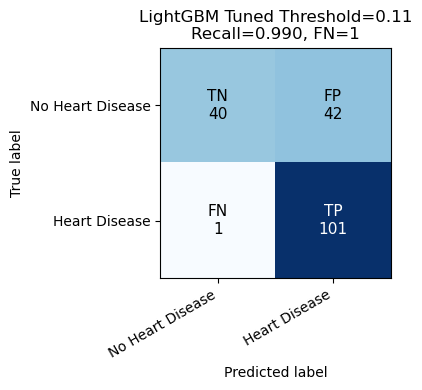

In [11]:
tuned_test_pred = (test_proba >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, tuned_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title(f"LightGBM Tuned Threshold={selected_threshold:.2f}\nRecall={lightgbm_tuned_result['Recall']:.3f}, FN={fn}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Heart Disease", "Heart Disease"], rotation=30, ha="right")
ax.set_yticklabels(["No Heart Disease", "Heart Disease"])

labels = [["TN", "FP"], ["FN", "TP"]]
threshold_for_text = cm.max() / 2
for row in range(2):
    for col in range(2):
        color = "white" if cm[row, col] > threshold_for_text else "black"
        ax.text(
            col,
            row,
            f"{labels[row][col]}\n{cm[row, col]}",
            ha="center",
            va="center",
            color=color,
            fontsize=11,
        )

fig.tight_layout()
fig.savefig(FIGURES_DIR / "lightgbm_tuned_confusion_matrix.png", dpi=150, bbox_inches="tight")

## 9. Update the Results Report

The tuned-threshold LightGBM row is appended to the existing model comparison. The default LightGBM row is kept so the impact of threshold tuning is visible.

In [12]:
def read_results_table(markdown_path):
    table_lines = [
        line.strip()
        for line in markdown_path.read_text(encoding="utf-8").splitlines()
        if line.strip().startswith("|")
    ]

    rows = []
    header = None

    for line in table_lines:
        values = [value.strip() for value in line.strip("|").split("|")]
        if all(set(value) <= {"-", ":"} for value in values):
            continue
        if header is None:
            header = values
        else:
            rows.append(values)

    results = pd.DataFrame(rows, columns=header)
    for column in results.columns:
        if column != "Model":
            results[column] = pd.to_numeric(results[column])

    return results


existing_results_df = read_results_table(REPORTS_DIR / "results.md")
existing_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]
existing_results_df = existing_results_df[
    existing_results_df["Model"].isin(existing_model_names)
].copy()

existing_results_df["Threshold"] = 0.50
tuned_results_df = pd.DataFrame([lightgbm_tuned_result])

comparison_columns = [
    "Model",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "True Negatives",
    "False Positives",
    "False Negatives",
    "True Positives",
]

comparison_df = pd.concat(
    [existing_results_df[comparison_columns], tuned_results_df[comparison_columns]],
    ignore_index=True,
)

write_results_markdown(
    comparison_df,
    REPORTS_DIR / "results.md",
    title="Model Comparison Results",
    model_group_name="baseline models, default LightGBM, and threshold-tuned LightGBM",
    best_model_label="model",
)

comparison_df

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,0.50,0.842000,0.835000,0.892000,0.86300,0.926000,64,18,11,91
1,Random Forest,0.50,0.848000,0.849000,0.882000,0.86500,0.928000,66,16,12,90
2,XGBoost,0.50,0.859000,0.852000,0.902000,0.87600,0.901000,66,16,10,92
3,LightGBM,0.50,0.842000,0.848000,0.873000,0.86000,0.928000,66,16,13,89
4,LightGBM tuned threshold,0.11,0.766304,0.706294,0.990196,0.82449,0.927666,40,42,1,101


## 10. Summary

The selected threshold greatly increases LightGBM recall and reduces false negatives. The cost is a large increase in false positives and lower precision.

For a screening-style medical model, this can be a reasonable direction because missed disease cases are more serious than extra follow-up checks. The exact threshold should still be treated as a clinical tradeoff, not a purely technical choice.

Hyperparameter tuning and SHAP interpretation are still future steps.